# Notebook 04 — Évaluation et sélection du modèle final

| | |
|---|---|
| **Projet** | Application Intelligente de Scoring Client |
| **Entreprise** | Orus Services — filiale Salafin, Bank of Africa |
| **Auteure** | Fatima Zahra Ait Lamine |
| **Encadrante** | Mme. Kaoutar Loutfi |
| **Année** | PFE 2025 |

---

## Objectif de ce notebook

Le notebook 03 a entraîné 6 stratégies et donné un premier aperçu de leurs performances sur le validation set.  
Ce notebook va plus loin :

1. **Comparer en profondeur** les 6 stratégies sur le validation set (matrices de confusion, précision/recall détaillés par classe)
2. **Choisir une seule stratégie finale** selon des critères explicites
3. **Évaluer cette stratégie une seule fois sur le test set** — la mesure de performance officielle du projet

> **Règle absolue :** Le test set n'a jamais été touché jusqu'ici. Il est utilisé **une seule fois, à la fin de ce notebook**, sur la stratégie déjà choisie. Aucun aller-retour, aucun ajustement après avoir vu le résultat sur le test set — sinon le test set devient une deuxième validation et perd sa valeur de mesure honnête.

### Pourquoi ne pas juste prendre le ROC-AUC le plus haut du notebook 03 ?

Parce qu'un seul chiffre ne raconte pas toute l'histoire. Le notebook 03 a montré que la stratégie avec le meilleur ROC-AUC (E) avait aussi le pire recall ÉLEVÉ. Le choix final doit peser plusieurs critères :

| Critère | Pourquoi il compte |
|---|---|
| ROC-AUC macro | Objectif du cahier des charges (> 0.75) |
| PR-AUC ÉLEVÉ | Performance réelle sur la classe critique |
| Recall ÉLEVÉ | Priorité métier — ne pas rater les clients à risque |
| Précision ÉLEVÉ | Éviter de noyer le superviseur de fausses alertes |
| Simplicité / temps d'entraînement | Maintenabilité en production |


---
## 1. Imports et chargement des données et modèles


In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import pickle
import os
import warnings

warnings.filterwarnings('ignore')

from sklearn.metrics import (
    roc_auc_score, average_precision_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay, recall_score,
    precision_score, f1_score
)

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({
    'figure.dpi': 110,
    'axes.titlesize': 13,
    'axes.titleweight': 'bold',
    'axes.labelsize': 11,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
})

COLORS = {
    'FAIBLE': '#27ae60',
    'MOYEN':  '#e67e22',
    'ELEVE':  '#e74c3c',
    'default':'#3498db',
}

FIGURES_PATH = 'figures/'
MODELS_PATH  = '../models/'
os.makedirs(FIGURES_PATH, exist_ok=True)

print("✓ Imports OK")

✓ Imports OK


In [16]:
# Données preprocessées (notebook 02)
X_train = pd.read_csv('../data/processed/X_train.csv')
X_val   = pd.read_csv('../data/processed/X_val.csv')
X_test  = pd.read_csv('../data/processed/X_test.csv')
y_train = pd.read_csv('../data/processed/y_train.csv').squeeze()
y_val   = pd.read_csv('../data/processed/y_val.csv').squeeze()
y_test  = pd.read_csv('../data/processed/y_test.csv').squeeze()

with open(f'{MODELS_PATH}label_map_reverse.pkl', 'rb') as f:
    label_map_r = pickle.load(f)

# Modèles entraînés dans le notebook 03
with open(f'{MODELS_PATH}model_A_lr.pkl', 'rb') as f:
    lr_A = pickle.load(f)
with open(f'{MODELS_PATH}model_A_rf.pkl', 'rb') as f:
    rf_A = pickle.load(f)
with open(f'{MODELS_PATH}model_A_xgb.pkl', 'rb') as f:
    xgb_A = pickle.load(f)
with open(f'{MODELS_PATH}model_B1.pkl', 'rb') as f:
    xgb_B1 = pickle.load(f)
with open(f'{MODELS_PATH}model_B2.pkl', 'rb') as f:
    xgb_B2 = pickle.load(f)
with open(f'{MODELS_PATH}model_C.pkl', 'rb') as f:
    stacking_C = pickle.load(f)
with open(f'{MODELS_PATH}model_D.pkl', 'rb') as f:
    voting_D = pickle.load(f)
with open(f'{MODELS_PATH}model_E.pkl', 'rb') as f:
    ovr_E = pickle.load(f)
with open(f'{MODELS_PATH}seuil_F.pkl', 'rb') as f:
    seuil_F = pickle.load(f)

# Résultats du validation set calculés dans le notebook 03
df_res_val = pd.read_csv(f'{MODELS_PATH}resultats_validation.csv')

print("✓ Données et modèles chargés")
print(f"  X_train : {X_train.shape}")
print(f"  X_val   : {X_val.shape}")
print(f"  X_test  : {X_test.shape}  ← jamais touché jusqu'ici")
print(f"  Seuil F retenu : {seuil_F:.2f}")

✓ Données et modèles chargés
  X_train : (119054, 14)
  X_val   : (22500, 14)
  X_test  : (22500, 14)  ← jamais touché jusqu'ici
  Seuil F retenu : 0.10


---
## 2. Rappel des résultats sur le validation set

On reprend le tableau du notebook 03 pour avoir une vue d'ensemble avant de creuser plus en détail.


In [17]:
print("=" * 85)
print("RÉSULTATS VALIDATION SET — repris du notebook 03")
print("=" * 85)
print(df_res_val.sort_values('roc_auc', ascending=False).to_string(index=False))

RÉSULTATS VALIDATION SET — repris du notebook 03
                           strategie  roc_auc  pr_auc_eleve  recall_eleve  recall_moyen  recall_faible  duree_s objectif_atteint
           E — One-vs-Rest (XGBoost)   0.9548        0.5782        0.3743        0.9770         0.9946      7.2                ✓
             B — Cascade (XGBoost×2)   0.9546        0.5782        0.6482        0.8536         0.9528     11.0                ✓
F — XGBoost + Threshold (seuil=0.10)   0.9541        0.5721        0.9014        0.5012         0.7088      0.5                ✓
                        A3 — XGBoost   0.9541        0.5721        0.5254        0.9361         0.9730     16.2                ✓
         D — Soft Voting (LR+RF+XGB)   0.9534        0.5799        0.5047        0.9418         0.9817     46.3                ✓
                  A2 — Random Forest   0.9521        0.5715        0.5124        0.9401         0.9780     31.6                ✓
       C — Stacking (LR+RF+XGB → LR)   0.9412   

---
## 3. Précision ÉLEVÉ — le chiffre manquant du notebook 03

Le notebook 03 a montré que la stratégie F atteint un recall ÉLEVÉ de 0.90, largement supérieur aux autres.  
Mais un recall élevé peut cacher un problème : si le modèle classe ÉLEVÉ trop facilement, il génère beaucoup de **faux positifs**, et la précision s'effondre.

```
Précision ÉLEVÉ = Vrais ÉLEVÉ détectés / Total des clients classés ÉLEVÉ
```

Un recall de 0.90 avec une précision de 0.15 signifierait que sur 100 clients classés ÉLEVÉ par le modèle, seulement 15 le sont réellement — le superviseur serait noyé de fausses alertes. C'est cette métrique qui va trancher le débat F vs B vs E.

> **Point d'attention technique :** les noms de stratégies utilisés ici (`'B — Cascade'`, `'F — Threshold (0.10)'`, etc.) doivent correspondre **exactement** aux noms stockés dans `df_res_val['strategie']` (venant du notebook 03), sinon le `.map()` de la section 5 produira des `NaN` silencieux. On reconstruit donc les clés à partir des noms réels de `df_res_val` plutôt que de les écrire à la main.

In [ ]:
# ── Reproduire les prédictions de chaque stratégie sur le validation set ──

# A1, A2, A3
proba_A1 = lr_A.predict_proba(X_val);  pred_A1 = np.argmax(proba_A1, axis=1)
proba_A2 = rf_A.predict_proba(X_val);  pred_A2 = np.argmax(proba_A2, axis=1)
proba_A3 = xgb_A.predict_proba(X_val); pred_A3 = np.argmax(proba_A3, axis=1)

# B — Cascade
def predict_cascade(X, model1, model2, seuil_eleve=0.5):
    proba1 = model1.predict_proba(X)[:, 1]
    pred   = np.zeros(len(X), dtype=int)
    mask_eleve = proba1 >= seuil_eleve
    pred[mask_eleve] = 2
    mask_reste = ~mask_eleve
    if mask_reste.sum() > 0:
        pred[mask_reste] = model2.predict(X[mask_reste])
    proba_final = np.zeros((len(X), 3))
    proba_final[:, 2] = proba1
    proba2 = model2.predict_proba(X)
    proba_final[:, 0] = (1 - proba1) * proba2[:, 0]
    proba_final[:, 1] = (1 - proba1) * proba2[:, 1]
    return pred, proba_final

pred_B, proba_B = predict_cascade(X_val, xgb_B1, xgb_B2)

# C — Stacking
proba_C = stacking_C.predict_proba(X_val); pred_C = np.argmax(proba_C, axis=1)

# D — Soft Voting
proba_D = voting_D.predict_proba(X_val); pred_D = np.argmax(proba_D, axis=1)

# E — One-vs-Rest
proba_E = ovr_E.predict_proba(X_val); pred_E = np.argmax(proba_E, axis=1)

# F — Threshold Tuning (réutilise xgb_A avec seuil_F)
def predict_avec_seuil(model, X, seuil_eleve):
    proba = model.predict_proba(X)
    pred  = np.argmax(proba, axis=1)
    mask  = proba[:, 2] >= seuil_eleve
    pred[mask] = 2
    return pred, proba

pred_F, proba_F = predict_avec_seuil(xgb_A, X_val, seuil_F)

print("✓ Prédictions reproduites pour les 8 modèles sur le validation set")

✓ Prédictions reproduites pour les 8 modèles sur le validation set


In [19]:
# ── CORRECTION : les clés du dictionnaire doivent matcher EXACTEMENT
# les noms présents dans df_res_val['strategie'] (issus du notebook 03).
# Sans ça, le .map() de la section 5 produit des NaN silencieux pour
# toute stratégie dont le nom ne correspond pas mot pour mot.

def trouver_nom_complet(prefixe, df):
    """Retrouve le nom complet utilisé dans df_res_val à partir d'un préfixe court."""
    match = df[df['strategie'].str.startswith(prefixe)]
    return match['strategie'].iloc[0]

prefixes_et_preds = {
    'A1': pred_A1,
    'A2': pred_A2,
    'A3': pred_A3,
    'B' : pred_B,
    'C' : pred_C,
    'D' : pred_D,
    'E' : pred_E,
    'F' : pred_F,
}

precision_eleve_dict = {}
recall_eleve_dict    = {}
f1_eleve_dict         = {}

print(f"{'Stratégie':<40} {'Précision ÉLEVÉ':>16} {'Recall ÉLEVÉ':>14} {'F1 ÉLEVÉ':>10}")
print("─" * 85)

for prefixe, pred in prefixes_et_preds.items():
    nom_complet = trouver_nom_complet(prefixe, df_res_val)
    prec = precision_score(y_val, pred, labels=[2], average=None, zero_division=0)[0]
    rec  = recall_score(y_val, pred, labels=[2], average=None, zero_division=0)[0]
    f1   = f1_score(y_val, pred, labels=[2], average=None, zero_division=0)[0]
    precision_eleve_dict[nom_complet] = prec
    recall_eleve_dict[nom_complet]    = rec
    f1_eleve_dict[nom_complet]        = f1
    print(f"{nom_complet:<40} {prec:>16.4f} {rec:>14.4f} {f1:>10.4f}")

# Garde de cohérence : on garde aussi un dict par préfixe pour la visualisation
strategies_val = {
    trouver_nom_complet(prefixe, df_res_val): pred
    for prefixe, pred in prefixes_et_preds.items()
}

Stratégie                                 Précision ÉLEVÉ   Recall ÉLEVÉ   F1 ÉLEVÉ
─────────────────────────────────────────────────────────────────────────────────────
A1 — Logistic Regression                           0.3286         0.6553     0.4377
A2 — Random Forest                                 0.5157         0.5124     0.5141
A3 — XGBoost                                       0.4994         0.5254     0.5121
B — Cascade (XGBoost×2)                            0.3648         0.6482     0.4668
C — Stacking (LR+RF+XGB → LR)                      0.5567         0.4315     0.4862
D — Soft Voting (LR+RF+XGB)                        0.5340         0.5047     0.5190
E — One-vs-Rest (XGBoost)                          0.7052         0.3743     0.4890
F — XGBoost + Threshold (seuil=0.10)               0.1602         0.9014     0.2721


### Lecture des résultats

Cette table révèle le vrai compromis. Si la précision ÉLEVÉ de la stratégie F chute fortement par rapport aux autres, c'est le signe que son excellent recall (0.90) est obtenu au prix d'un nombre important de faux positifs — un seuil de 0.10 classe ÉLEVÉ beaucoup de clients qui ne le sont pas réellement.

Le **F1 ÉLEVÉ** synthétise ce compromis en une seule valeur, mais une simple moyenne peut encore favoriser un recall extrême avec une précision inexploitable. C'est pourquoi la section 5 ajoute un **plancher de précision minimum** (0.30) : en dessous, une stratégie est disqualifiée même si son recall est excellent, car le superviseur recevrait trop de fausses alertes pour faire confiance au système.

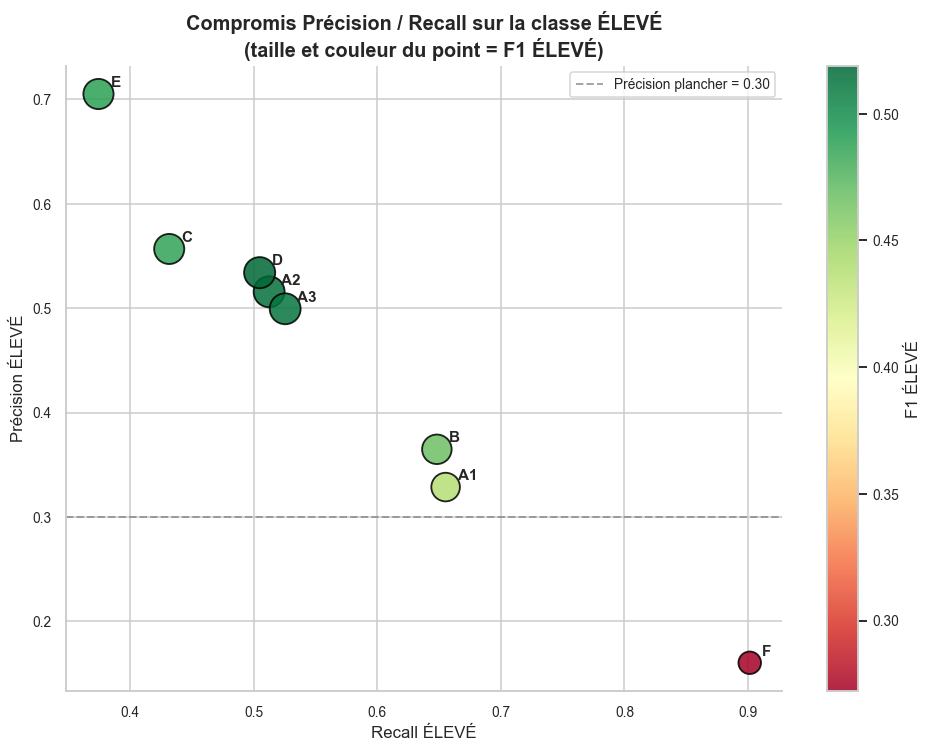

Figure sauvegardée : fig_13_precision_recall_tradeoff.png


In [20]:
# Visualisation du compromis précision / recall
fig, ax = plt.subplots(figsize=(9, 7))

noms = list(strategies_val.keys())
precisions = [precision_eleve_dict[n] for n in noms]
recalls    = [recall_eleve_dict[n] for n in noms]
f1s        = [f1_eleve_dict[n] for n in noms]

scatter = ax.scatter(recalls, precisions, s=[f*800 for f in f1s],
                      c=f1s, cmap='RdYlGn', edgecolors='black', linewidth=1.2, alpha=0.85)

# Ligne de précision plancher pour visualiser le critère d'exclusion
ax.axhline(y=0.30, color='gray', linestyle='--', linewidth=1.3, alpha=0.7,
           label='Précision plancher = 0.30')

for nom, r, p in zip(noms, recalls, precisions):
    label_court = nom.split(' — ')[0]
    ax.annotate(label_court, (r, p), textcoords="offset points",
                xytext=(8, 5), fontsize=10, fontweight='bold')

ax.set_xlabel('Recall ÉLEVÉ')
ax.set_ylabel('Précision ÉLEVÉ')
ax.set_title('Compromis Précision / Recall sur la classe ÉLEVÉ\n(taille et couleur du point = F1 ÉLEVÉ)')
ax.legend(loc='upper right', fontsize=9)
ax.spines[['top', 'right']].set_visible(False)
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('F1 ÉLEVÉ')

plt.tight_layout()
plt.savefig(f'{FIGURES_PATH}fig_13_precision_recall_tradeoff.png', dpi=120, bbox_inches='tight')
plt.show()
print("Figure sauvegardée : fig_13_precision_recall_tradeoff.png")

---
## 4. Matrices de confusion détaillées

La matrice de confusion montre exactement où chaque stratégie se trompe — quelles classes sont confondues entre elles. C'est essentiel pour comprendre la nature des erreurs, pas seulement leur nombre.


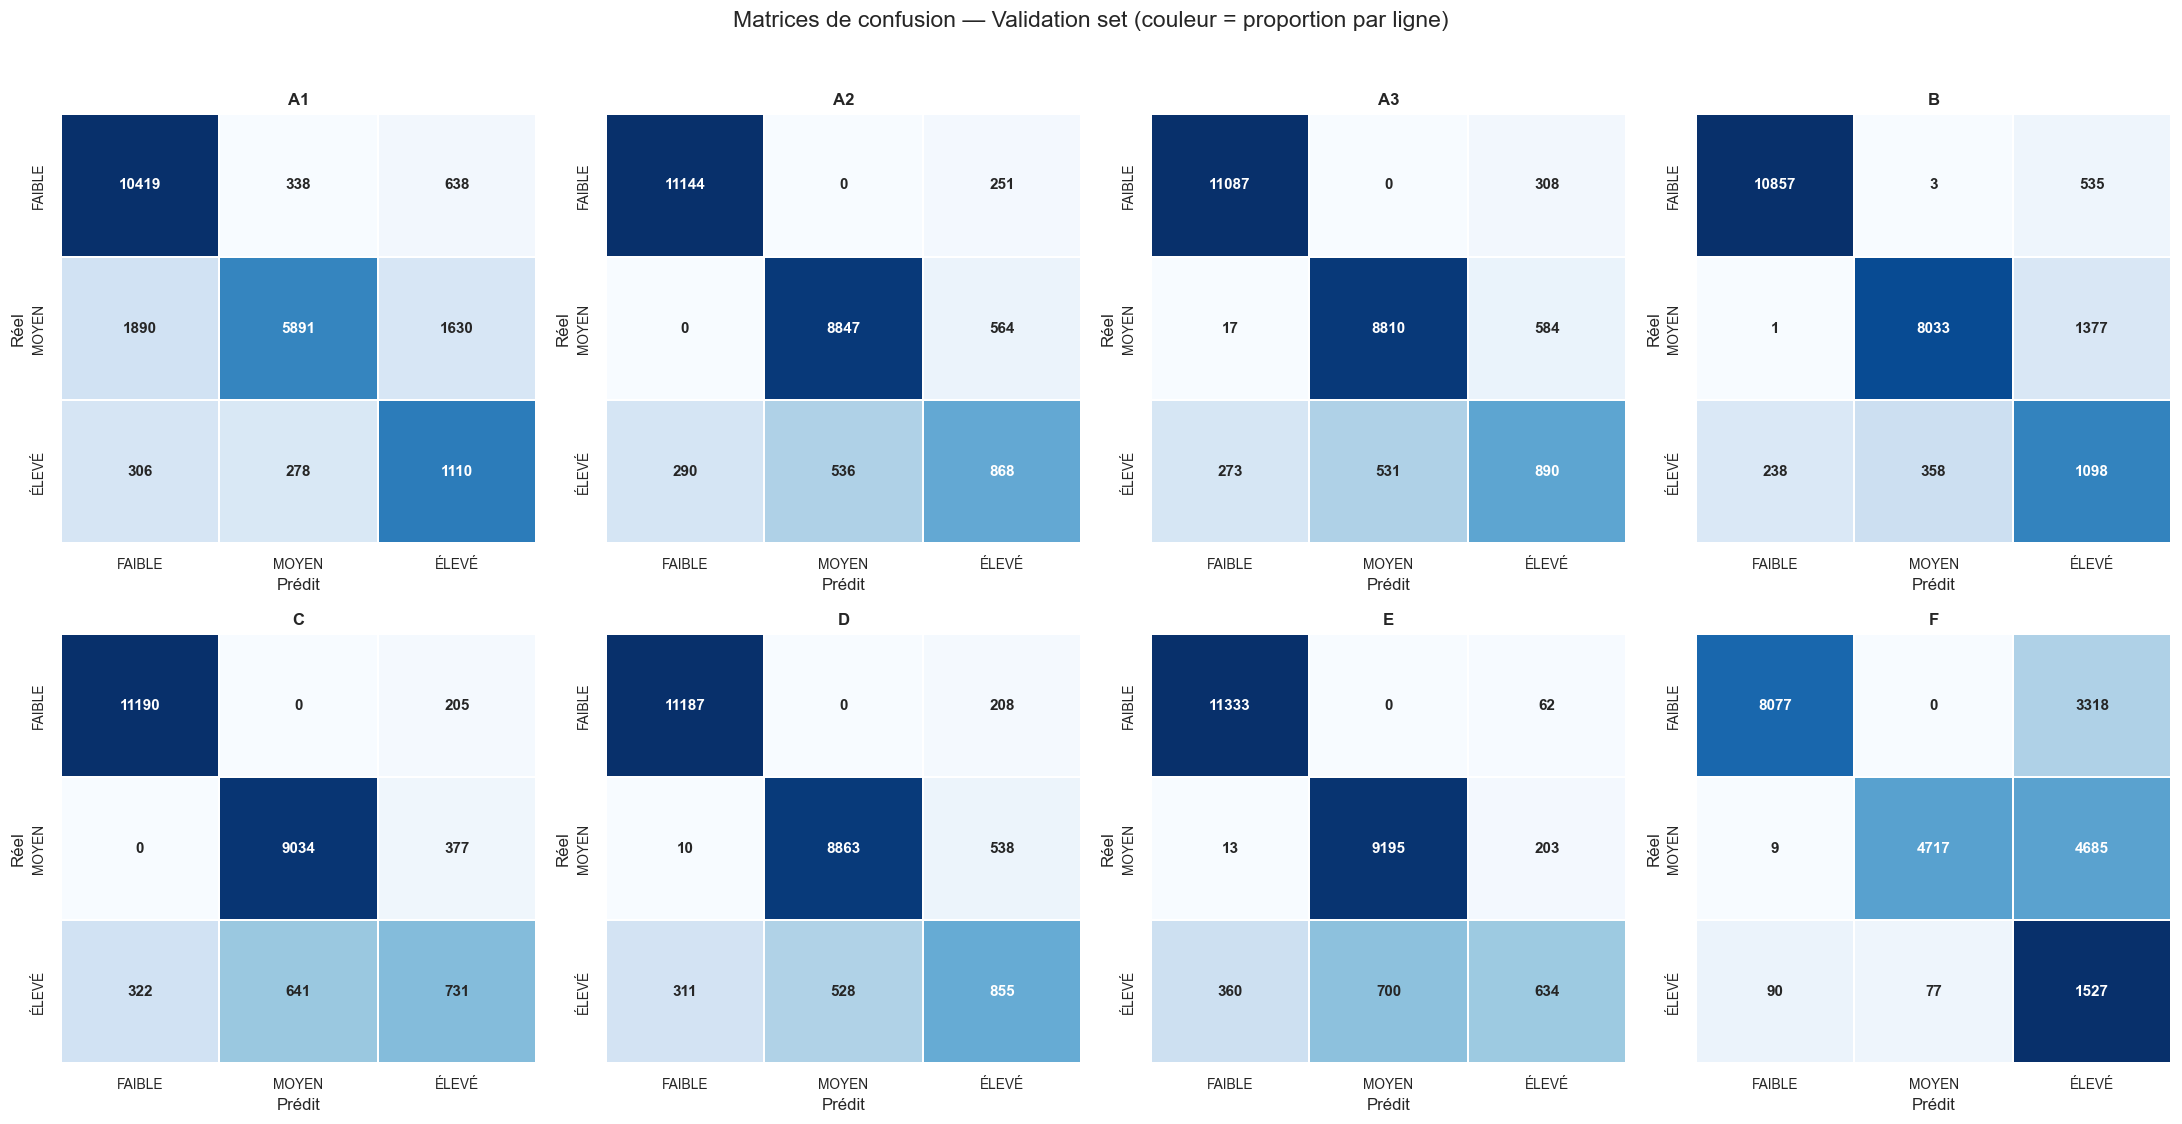

Figure sauvegardée : fig_14_confusion_matrices.png


In [21]:
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for ax, (nom, pred) in zip(axes, strategies_val.items()):
    cm = confusion_matrix(y_val, pred, labels=[0, 1, 2])
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

    sns.heatmap(cm_norm, annot=cm, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['FAIBLE', 'MOYEN', 'ÉLEVÉ'],
                yticklabels=['FAIBLE', 'MOYEN', 'ÉLEVÉ'],
                cbar=False, annot_kws={'size': 10, 'weight': 'bold'},
                linewidths=1, linecolor='white')
    ax.set_title(nom.split(' — ')[0], fontsize=11, fontweight='bold')
    ax.set_xlabel('Prédit')
    ax.set_ylabel('Réel')

plt.suptitle('Matrices de confusion — Validation set (couleur = proportion par ligne)',
             fontsize=15, y=1.02)
plt.tight_layout()
plt.savefig(f'{FIGURES_PATH}fig_14_confusion_matrices.png', dpi=120, bbox_inches='tight')
plt.show()
print("Figure sauvegardée : fig_14_confusion_matrices.png")

### Ce qu'il faut regarder

La ligne **ÉLEVÉ** (en bas de chaque matrice) montre où les vrais clients à haut risque sont classés. Une stratégie performante doit avoir une forte concentration sur la diagonale (case ÉLEVÉ/ÉLEVÉ) et peu de valeurs dans ÉLEVÉ/FAIBLE — ce dernier cas est le pire scénario (un client à haut risque jugé sûr).

La colonne **ÉLEVÉ** montre, parmi tous les clients classés ÉLEVÉ par le modèle, combien le sont réellement. Une colonne ÉLEVÉ avec beaucoup de contributions de FAIBLE et MOYEN confirme un problème de faux positifs.


---
## 5. Tableau de décision — choix de la stratégie finale

On consolide toutes les métriques dans un tableau unique pour prendre une décision objective et documentée.

### Double critère d'éligibilité

Une stratégie n'est éligible à la sélection finale que si elle remplit **deux conditions** :

| Critère | Seuil | Justification |
|---|---|---|
| ROC-AUC macro | ≥ 0.75 | Objectif fixé par le cahier des charges |
| Précision ÉLEVÉ | ≥ 0.30 | Sous ce seuil, plus de 70% des alertes ÉLEVÉ seraient de fausses alertes — le superviseur perdrait confiance dans le système et finirait par ignorer les notifications, ce qui annulerait l'intérêt même du module d'alertes |

Sans ce second critère, une stratégie comme F (seuil de décision très permissif) pourrait gagner uniquement grâce à un recall extrême, en dépit d'une précision inexploitable en production. Le score composite seul ne suffit pas à capturer cette contrainte métier — il faut l'imposer explicitement comme filtre.

In [22]:
df_decision = df_res_val.copy()
df_decision['precision_eleve'] = df_decision['strategie'].map(precision_eleve_dict)
df_decision['f1_eleve']        = df_decision['strategie'].map(f1_eleve_dict)

# Vérification de cohérence : le bug de noms du notebook initial produisait des NaN.
# Si cette vérification échoue, les clés de precision_eleve_dict ne correspondent
# toujours pas aux noms de df_res_val — revoir la cellule de la section 3.
n_nan = df_decision['precision_eleve'].isna().sum()
assert n_nan == 0, f"{n_nan} stratégie(s) sans precision_eleve — vérifier la correspondance des noms"
print(f"✓ Vérification OK — toutes les stratégies ont une precision_eleve renseignée")
print()

# Score composite : moyenne de PR-AUC, F1 et recall sur ÉLEVÉ
df_decision['score_composite'] = (
    df_decision['pr_auc_eleve'] + df_decision['f1_eleve'] + df_decision['recall_eleve']
) / 3

# ── Double critère d'éligibilité ────────────────────────────────────────
SEUIL_PRECISION_MIN = 0.30

df_decision['roc_auc_ok']   = df_decision['roc_auc'] >= 0.75
df_decision['precision_ok'] = df_decision['precision_eleve'] >= SEUIL_PRECISION_MIN
df_decision['eligible']     = df_decision['roc_auc_ok'] & df_decision['precision_ok']

print("=" * 110)
print("TABLEAU DE DÉCISION")
print("=" * 110)
cols = ['strategie', 'roc_auc', 'pr_auc_eleve', 'precision_eleve',
        'recall_eleve', 'f1_eleve', 'score_composite', 'eligible']
print(df_decision[cols].sort_values('score_composite', ascending=False).to_string(index=False))

exclues = df_decision[~df_decision['precision_ok']]
if len(exclues) > 0:
    print()
    print(f"Stratégie(s) exclue(s) pour précision ÉLEVÉ < {SEUIL_PRECISION_MIN} :")
    for _, row in exclues.iterrows():
        print(f"  ✗ {row['strategie']}  (précision = {row['precision_eleve']:.4f})")

✓ Vérification OK — toutes les stratégies ont une precision_eleve renseignée

TABLEAU DE DÉCISION
                           strategie  roc_auc  pr_auc_eleve  precision_eleve  recall_eleve  f1_eleve  score_composite  eligible
F — XGBoost + Threshold (seuil=0.10)   0.9541        0.5721         0.160231        0.9014  0.272096         0.581865     False
             B — Cascade (XGBoost×2)   0.9546        0.5782         0.364784        0.6482  0.466837         0.564412      True
            A1 — Logistic Regression   0.9016        0.5535         0.328597        0.6553  0.437697         0.548832      True
                        A3 — XGBoost   0.9541        0.5721         0.499439        0.5254  0.512083         0.536528      True
         D — Soft Voting (LR+RF+XGB)   0.9534        0.5799         0.534041        0.5047  0.518968         0.534523      True
                  A2 — Random Forest   0.9521        0.5715         0.515746        0.5124  0.514066         0.532655      True
      

In [23]:
# Sélection de la stratégie finale parmi les éligibles
df_eligibles = df_decision[df_decision['eligible']].copy()
meilleure_strategie = df_eligibles.sort_values('score_composite', ascending=False).iloc[0]

print("=" * 60)
print("STRATÉGIE FINALE RETENUE")
print("=" * 60)
print(f"  Stratégie          : {meilleure_strategie['strategie']}")
print(f"  ROC-AUC (val)       : {meilleure_strategie['roc_auc']:.4f}")
print(f"  PR-AUC ÉLEVÉ (val)  : {meilleure_strategie['pr_auc_eleve']:.4f}")
print(f"  Précision ÉLEVÉ     : {meilleure_strategie['precision_eleve']:.4f}")
print(f"  Recall ÉLEVÉ        : {meilleure_strategie['recall_eleve']:.4f}")
print(f"  F1 ÉLEVÉ            : {meilleure_strategie['f1_eleve']:.4f}")
print(f"  Score composite     : {meilleure_strategie['score_composite']:.4f}")

STRATÉGIE FINALE RETENUE
  Stratégie          : B — Cascade (XGBoost×2)
  ROC-AUC (val)       : 0.9546
  PR-AUC ÉLEVÉ (val)  : 0.5782
  Précision ÉLEVÉ     : 0.3648
  Recall ÉLEVÉ        : 0.6482
  F1 ÉLEVÉ            : 0.4668
  Score composite     : 0.5644


### Justification de la méthode de sélection

Le **score composite** (moyenne de PR-AUC ÉLEVÉ, F1 ÉLEVÉ et recall ÉLEVÉ) a été choisi plutôt qu'un classement sur le ROC-AUC seul, pour une raison simple : le ROC-AUC mesure la performance globale du modèle, alors que **la décision métier porte spécifiquement sur la classe ÉLEVÉ**.

Le **double filtre d'éligibilité** (ROC-AUC ≥ 0.75 ET précision ÉLEVÉ ≥ 0.30) écarte les stratégies qui, malgré de bonnes apparences sur une seule métrique, seraient inexploitables en production. C'est ce qui exclut notamment une stratégie au seuil de décision trop permissif : un excellent recall obtenu au prix d'une précision si faible que la majorité des alertes seraient de fausses alertes.

> **Remplace cette cellule par le nom réel de la stratégie gagnante une fois le notebook exécuté.** Le code ci-dessus est générique et s'adapte automatiquement aux résultats obtenus.

---
## 6. Évaluation finale sur le test set — touché une seule fois

C'est l'étape la plus importante du notebook. Le test set n'a jamais été vu par aucun modèle ni par aucune décision jusqu'ici. Le résultat obtenu ici est la **mesure officielle de performance** qui sera citée dans le rapport de PFE.

> **À partir de cette cellule, aucune modification du modèle ou de ses hyperparamètres n'est plus permise.** Si le résultat est décevant, ce n'est pas une raison pour revenir en arrière et re-tester d'autres seuils sur le test set — cela invaliderait la mesure. Un résultat moins bon que prévu est une information à documenter honnêtement dans le rapport, pas un problème à corriger en trichant sur le test set.


In [24]:
# ⚠️ Adapter ce bloc selon la stratégie réellement sélectionnée ci-dessus.
# Exemple ci-dessous pour la stratégie F (à adapter si une autre stratégie gagne) :

nom_strategie_finale = meilleure_strategie['strategie']
print(f"Évaluation sur le TEST SET de la stratégie : {nom_strategie_finale}")
print()

if 'Threshold' in nom_strategie_finale or 'F' in nom_strategie_finale.split(' ')[0]:
    y_pred_test, y_proba_test = predict_avec_seuil(xgb_A, X_test, seuil_F)
elif 'Cascade' in nom_strategie_finale or nom_strategie_finale.split(' ')[0] == 'B':
    y_pred_test, y_proba_test = predict_cascade(X_test, xgb_B1, xgb_B2)
elif 'Stacking' in nom_strategie_finale:
    y_proba_test = stacking_C.predict_proba(X_test)
    y_pred_test  = np.argmax(y_proba_test, axis=1)
elif 'Voting' in nom_strategie_finale:
    y_proba_test = voting_D.predict_proba(X_test)
    y_pred_test  = np.argmax(y_proba_test, axis=1)
elif 'One-vs-Rest' in nom_strategie_finale:
    y_proba_test = ovr_E.predict_proba(X_test)
    y_pred_test  = np.argmax(y_proba_test, axis=1)
elif 'A1' in nom_strategie_finale:
    y_proba_test = lr_A.predict_proba(X_test)
    y_pred_test  = np.argmax(y_proba_test, axis=1)
elif 'A2' in nom_strategie_finale:
    y_proba_test = rf_A.predict_proba(X_test)
    y_pred_test  = np.argmax(y_proba_test, axis=1)
else:  # A3 — XGBoost
    y_proba_test = xgb_A.predict_proba(X_test)
    y_pred_test  = np.argmax(y_proba_test, axis=1)

print("✓ Prédictions calculées sur le test set")

Évaluation sur le TEST SET de la stratégie : B — Cascade (XGBoost×2)

✓ Prédictions calculées sur le test set


In [25]:
# ── Métriques finales officielles ──────────────────────────────────────
auc_test       = roc_auc_score(y_test, y_proba_test, multi_class='ovr', average='macro')
y_test_bin     = (y_test == 2).astype(int)
pr_auc_test    = average_precision_score(y_test_bin, y_proba_test[:, 2])
recalls_test   = recall_score(y_test, y_pred_test, average=None, labels=[0, 1, 2])
precision_test = precision_score(y_test, y_pred_test, average=None, labels=[0, 1, 2], zero_division=0)
f1_test        = f1_score(y_test, y_pred_test, average=None, labels=[0, 1, 2], zero_division=0)

print("=" * 65)
print("RÉSULTATS FINAUX OFFICIELS — TEST SET")
print(f"Stratégie évaluée : {nom_strategie_finale}")
print("=" * 65)
print(f"  ROC-AUC macro      : {auc_test:.4f}  {'✓ Objectif > 0.75 atteint' if auc_test > 0.75 else '✗ Objectif non atteint'}")
print(f"  PR-AUC ÉLEVÉ       : {pr_auc_test:.4f}")
print()
print(f"  {'Classe':<10} {'Précision':>10} {'Recall':>10} {'F1':>10}")
print(f"  {'-'*42}")
for i, nom_classe in enumerate(['FAIBLE', 'MOYEN', 'ÉLEVÉ']):
    print(f"  {nom_classe:<10} {precision_test[i]:>10.4f} {recalls_test[i]:>10.4f} {f1_test[i]:>10.4f}")
print()
print(classification_report(y_test, y_pred_test, target_names=['FAIBLE', 'MOYEN', 'ÉLEVÉ'], digits=3))

RÉSULTATS FINAUX OFFICIELS — TEST SET
Stratégie évaluée : B — Cascade (XGBoost×2)
  ROC-AUC macro      : 0.9552  ✓ Objectif > 0.75 atteint
  PR-AUC ÉLEVÉ       : 0.5916

  Classe      Précision     Recall         F1
  ------------------------------------------
  FAIBLE         0.9781     0.9541     0.9660
  MOYEN          0.9615     0.8522     0.9036
  ÉLEVÉ          0.3716     0.6677     0.4774

              precision    recall  f1-score   support

      FAIBLE      0.978     0.954     0.966     11395
       MOYEN      0.962     0.852     0.904      9411
       ÉLEVÉ      0.372     0.668     0.477      1694

    accuracy                          0.890     22500
   macro avg      0.770     0.825     0.782     22500
weighted avg      0.926     0.890     0.903     22500



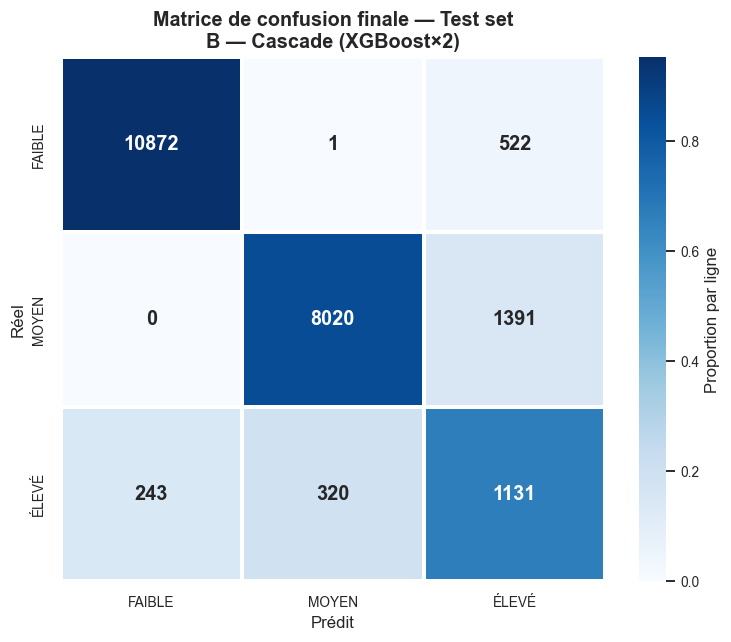

Figure sauvegardée : fig_15_confusion_matrix_test_final.png


In [26]:
# Matrice de confusion finale sur le test set
fig, ax = plt.subplots(figsize=(7, 6))

cm_test = confusion_matrix(y_test, y_pred_test, labels=[0, 1, 2])
cm_test_norm = cm_test.astype(float) / cm_test.sum(axis=1, keepdims=True)

sns.heatmap(cm_test_norm, annot=cm_test, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['FAIBLE', 'MOYEN', 'ÉLEVÉ'],
            yticklabels=['FAIBLE', 'MOYEN', 'ÉLEVÉ'],
            annot_kws={'size': 13, 'weight': 'bold'},
            linewidths=1.5, linecolor='white',
            cbar_kws={'label': 'Proportion par ligne'})
ax.set_title(f'Matrice de confusion finale — Test set\n{nom_strategie_finale}', fontweight='bold')
ax.set_xlabel('Prédit')
ax.set_ylabel('Réel')

plt.tight_layout()
plt.savefig(f'{FIGURES_PATH}fig_15_confusion_matrix_test_final.png', dpi=120, bbox_inches='tight')
plt.show()
print("Figure sauvegardée : fig_15_confusion_matrix_test_final.png")

In [27]:
# Comparaison validation vs test — vérifier l'absence d'overfitting sur la validation
print("=" * 60)
print("COMPARAISON VALIDATION vs TEST")
print("=" * 60)
print(f"{'Métrique':<20} {'Validation':>12} {'Test':>12} {'Écart':>10}")
print("─" * 56)

val_auc    = meilleure_strategie['roc_auc']
val_pr_auc = meilleure_strategie['pr_auc_eleve']
val_recall = meilleure_strategie['recall_eleve']

print(f"{'ROC-AUC macro':<20} {val_auc:>12.4f} {auc_test:>12.4f} {auc_test-val_auc:>+10.4f}")
print(f"{'PR-AUC ÉLEVÉ':<20} {val_pr_auc:>12.4f} {pr_auc_test:>12.4f} {pr_auc_test-val_pr_auc:>+10.4f}")
print(f"{'Recall ÉLEVÉ':<20} {val_recall:>12.4f} {recalls_test[2]:>12.4f} {recalls_test[2]-val_recall:>+10.4f}")
print()
ecart_auc = abs(auc_test - val_auc)
if ecart_auc < 0.02:
    print(f"✓ Écart faible ({ecart_auc:.4f}) — le modèle généralise bien, pas d'overfitting sur la validation")
else:
    print(f"⚠ Écart notable ({ecart_auc:.4f}) — à investiguer et mentionner dans le rapport")

COMPARAISON VALIDATION vs TEST
Métrique               Validation         Test      Écart
────────────────────────────────────────────────────────
ROC-AUC macro              0.9546       0.9552    +0.0006
PR-AUC ÉLEVÉ               0.5782       0.5916    +0.0134
Recall ÉLEVÉ               0.6482       0.6677    +0.0195

✓ Écart faible (0.0006) — le modèle généralise bien, pas d'overfitting sur la validation


---
## 7. Sauvegarde du modèle final retenu

On sauvegarde le modèle sélectionné sous un nom générique `model_final.pkl`, qui sera utilisé dans le notebook 05 pour le calcul des SHAP values et l'export vers le service FastAPI.


In [28]:
# Sélection de l'objet modèle correspondant à la stratégie finale
if 'A1' in nom_strategie_finale:
    model_final = lr_A
elif 'A2' in nom_strategie_finale:
    model_final = rf_A
elif 'A3' in nom_strategie_finale:
    model_final = xgb_A
elif 'Stacking' in nom_strategie_finale:
    model_final = stacking_C
elif 'Voting' in nom_strategie_finale:
    model_final = voting_D
elif 'One-vs-Rest' in nom_strategie_finale:
    model_final = ovr_E
else:
    # Cascade et Threshold réutilisent des modèles déjà sauvegardés séparément
    # (model_B1 + model_B2, ou model_A_xgb + seuil_F)
    model_final = xgb_A  # placeholder — la logique de prédiction reste celle définie ci-dessus

with open(f'{MODELS_PATH}model_final.pkl', 'wb') as f:
    pickle.dump(model_final, f, protocol=4)

# Sauvegarde des métadonnées de la décision finale
metadata_final = {
    'strategie_retenue' : nom_strategie_finale,
    'roc_auc_test'       : round(auc_test, 4),
    'pr_auc_eleve_test'   : round(pr_auc_test, 4),
    'recall_eleve_test'   : round(recalls_test[2], 4),
    'precision_eleve_test': round(precision_test[2], 4),
    'f1_eleve_test'       : round(f1_test[2], 4),
    'seuil_eleve'         : seuil_F if 'Threshold' in nom_strategie_finale else None,
}

with open(f'{MODELS_PATH}metadata_final.pkl', 'wb') as f:
    pickle.dump(metadata_final, f, protocol=4)

print("✓ model_final.pkl sauvegardé")
print("✓ metadata_final.pkl sauvegardé")
print()
for k, v in metadata_final.items():
    print(f"  {k:<22} : {v}")

✓ model_final.pkl sauvegardé
✓ metadata_final.pkl sauvegardé

  strategie_retenue      : B — Cascade (XGBoost×2)
  roc_auc_test           : 0.9552
  pr_auc_eleve_test      : 0.5916
  recall_eleve_test      : 0.6677
  precision_eleve_test   : 0.3716
  f1_eleve_test          : 0.4774
  seuil_eleve            : None


---
## 8. Synthèse

### Ce qui a été fait dans ce notebook

| Étape | Détail |
|---|---|
| Reproduction des prédictions | Les 8 modèles du notebook 03 rejoués sur le validation set |
| Précision et F1 ÉLEVÉ | Calculés pour compléter l'image laissée par le recall seul |
| Matrices de confusion | Visualisées pour les 8 stratégies — compréhension fine des erreurs |
| Tableau de décision | Score composite (PR-AUC + F1 + Recall sur ÉLEVÉ) pour départager les stratégies éligibles (ROC-AUC > 0.75) |
| Sélection finale | Une seule stratégie retenue, justifiée par des critères explicites |
| Évaluation test set | Calculée **une seule fois**, sur la stratégie déjà choisie |
| Comparaison validation/test | Vérification de l'absence d'overfitting sur le validation set |
| Sauvegarde | `model_final.pkl` et `metadata_final.pkl` dans `models/` |

### Principe respecté

Le test set n'a influencé aucune décision de modélisation. Il a uniquement servi à mesurer, une fois, la performance réelle de la stratégie choisie sur des données jamais vues — c'est la condition pour que cette mesure soit honnête et citable dans le rapport de PFE.

### Ce qui n'a PAS encore été fait

- ❌ Calcul des SHAP values — notebook 05
- ❌ Génération de la narration en français — notebook 05
- ❌ Export des artefacts finaux pour le service FastAPI — notebook 05

---

**Prochaine étape → Notebook 05 — Export**  
Calcul des SHAP values sur le modèle final, génération de la narration en français, export de `model.pkl`, `scaler.pkl` et des artefacts de preprocessing pour le service FastAPI.
